# Match spots in STED detail images

- Take dataframe of spots detected in STED detail images `spot_subfolder`.
- Combine the spots from channel 0 (eg. promoter) and channel 1 (eg. enhancer) in each image. Channel number is adjustable with `channels`.
- Calculate distances between each pair.
- Filter for images with exact number of enhnacers `n_enh` with max channel 0 - 1 distance `limit`.
- Save result to `merge_distances.csv`.
- Get list of "good" images (utilized in the `merge_distances.csv` dataframe).
- Link detection projections of those images into `projections_subfolder`.

In [110]:
import numpy as np
import pandas as pd
import seaborn as sns

import os
import csv
import shutil
import glob

In [138]:
in_path = "/data/agl_data/NanoFISH/Gabi/GS487_Dppa3_all_mESC_RNA-DNA/20240803_DNAFISH/"
spot_subfolder = "detections_sted_0.015/merge_global_coords.csv"
out_subfolder = "detections_sted_0.015"
projections_subfolder = "detections_sted_0.015/vis"
projections_vis_subfolder = "detections_good/"

# pixel_size = [0.03, 0.03, 0.15]  # pixel size x,y,z
# pixel_size = [0.045, 0.045, 0.06]  # pixel size x,y,z
pixel_size = [1, 1, 1]
limit = 1.5 #max P-E distance to look at [um]
n_enh = 3
channels = [0,1] # fisrt is promoter channel, second is enhancer channel
# xyz = ['x', 'y', 'z']
xyz = ['x_global_um','y_global_um','z_global_um']
filter_enh = False # filter for exact n_enh (if True: == n_enh, if False: <= n_enh)


In [139]:
# join the 2 spot channels
def join_channels(data,pixel_size,limit,n_enh,channels,xyz,intensity):

    data =  data[((data['channel'] == channels[1]) & (data['intensity'] >= intensity)) | (data['channel'] == channels[0])]
    data=data.copy()
    
    # Step 1: Group by 'img' and 'channel', then mutate 'n'
    data['n'] = data.groupby(['img', 'channel'])['channel'].transform('size')
    
    # Step 2: Apply filter conditions
    data1 = data[((data['channel'] == channels[0]) & (data['n'] == 1)) |
                 ((data['channel'] == channels[1]) & (data['n'] > 0) & (data['n'] <= n_enh))]
    
    # Step 3: Select specific columns and mutate 'img'
    data2 = data1[['img', 'channel', xyz[0],  xyz[1],  xyz[2], 'n', 'experiment.cell_type', 'preparation.date']].copy()
    data2['img'] = data2['img'].str.replace(r"_ch.*$", "", regex=True)
    
    # Step 4: Create separate DataFrames for 'channel' == 0 and 'channel' == 1
    df0 = data2[data2['channel'] == channels[0]]
    df1 = data2[data2['channel'] == channels[1]]
    
    # Step 5: Perform a right join on 'img' and drop NAs
    df = pd.merge(df0, df1, on='img', suffixes=('_0', '_1'), how='right').dropna()
    
    # Step 6: Calculate the 3D length ('len3d')
    df['len3d'] = np.sqrt(
        ((df[f"{xyz[0]}_0"] - df[f"{xyz[0]}_1"]) * pixel_size[0])**2 +
        ((df[f"{xyz[1]}_0"] - df[f"{xyz[1]}_1"]) * pixel_size[1])**2 +
        ((df[f"{xyz[2]}_0"] - df[f"{xyz[2]}_1"]) * pixel_size[2])**2
    )
    
    # Step 7: Filter by 'len3d' and group by 'img', then mutate 'n_1'
    df = df[df['len3d'] <= limit]
    df['n_1'] = df.groupby('img')['img'].transform('size')
    
    if filter_enh == True:
        df = df[df['n_1']==n_enh]
    elif filter_enh == False:
        df = df[df['n_1']<=n_enh]
        
    df = df[df['img'].str.contains('sted')]

    return(df)

# plot good detections
def plot_good_imgs(csv_file,search_directory,output_directory):

    good_imgs = []
    
    # Ensure the output directory exists
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)
    
    # Set to hold core filenames
    core_filenames = set()
    
    # Read the CSV file and extract core filenames
    with open(csv_file) as f:
        reader = csv.reader(f)
        imgs = list(reader)
    
    imgs = [item for sublist in imgs for item in sublist]
    
    # get images which match the input list
    for img in imgs:
        name = os.path.basename(img)
    
        # get matching files
        search_pattern = f"*{name}_*"
        good_img = glob.glob(os.path.join(search_directory, search_pattern))
        good_imgs.append(good_img)
    
    good_imgs1 = [item for sublist in good_imgs for item in sublist]
    
    # create symlink
    for file_path in good_imgs1:
        # Get the base name of the file 
        file_name = os.path.basename(file_path)
        
        # Construct the symlink path in the destination directory
        symlink_path = os.path.join(output_directory, file_name)
        
        try:
            # Create the symlink
            os.symlink(file_path, symlink_path)
        except FileExistsError:
            print(f'Symlink already exists for {file_path} -> {symlink_path}')
        except Exception as e:
            print(f'Error creating symlink for {file_path}: {e}')

def create_folder(folder_path):
    
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

# 1) Match spot pairs and filter for number of enhancers

Total of  147 images.


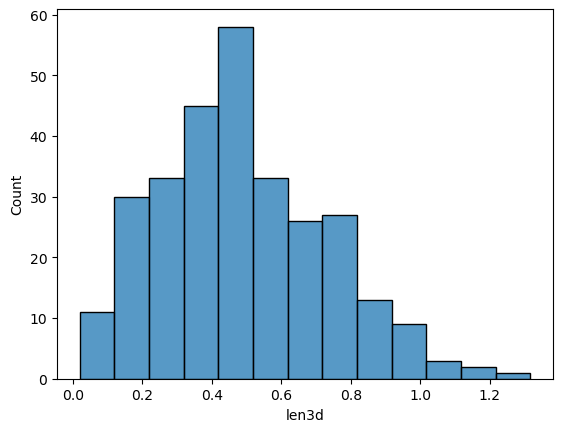

In [143]:
# process data
data = pd.read_csv(f"{in_path}/{spot_subfolder}")
distances = join_channels(data,pixel_size,limit,n_enh,channels,xyz,0)

# save data 
if filter_enh == True:
    distances.to_csv(f"{in_path}/{out_subfolder}/merge_distances.csv",index=False)
elif filter_enh == False:
    distances.to_csv(f"{in_path}/{out_subfolder}/merge_distances_all_n.csv",index=False)

sns.histplot(distances, x="len3d",binwidth=0.1)

print("Total of ", len(distances[['img']].drop_duplicates()), "images.")

# 2) Get list of used images and create a seperate subfolder with their detections

In [124]:
# get good images and create folder with the detections
good_imgs = distances[['img']].drop_duplicates()

# save good imgs
good_imgs_path = f"{in_path}/{projections_subfolder}"
create_folder(good_imgs_path)
good_imgs.to_csv(f"{good_imgs_path}/good_imgs.csv",index=False)

plot_good_imgs(f"{good_imgs_path}/good_imgs.csv",\
               f"{in_path}/{projections_vis_subfolder}",\
               f"{in_path}/{projections_subfolder}")